In [1]:
# Importing DIrectory 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r"C:\Users\16124\OneDrive\Desktop\Project folder 6")
print(os.getcwd())

C:\Users\16124\OneDrive\Desktop\Project folder 6


In [2]:
# Loading data 
prepared_path = "data/prepared/"
viz_path = "visualizations/"

df = pd.read_csv(prepared_path + "cdi_overall_wide.csv")

print("Shape:", df.shape)
print("Years available:", sorted(df['YearStart'].unique()))

Shape: (450, 8)
Years available: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [3]:
# Checking data by the year 
year_counts = df.dropna(
    subset=['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']
).groupby('YearStart')['LocationAbbr'].count()

print(year_counts)

YearStart
2011    41
2012    41
2013    41
2014    41
2015    41
2016    41
2017    41
2018    41
2019    40
2020    41
2021    41
Name: LocationAbbr, dtype: int64


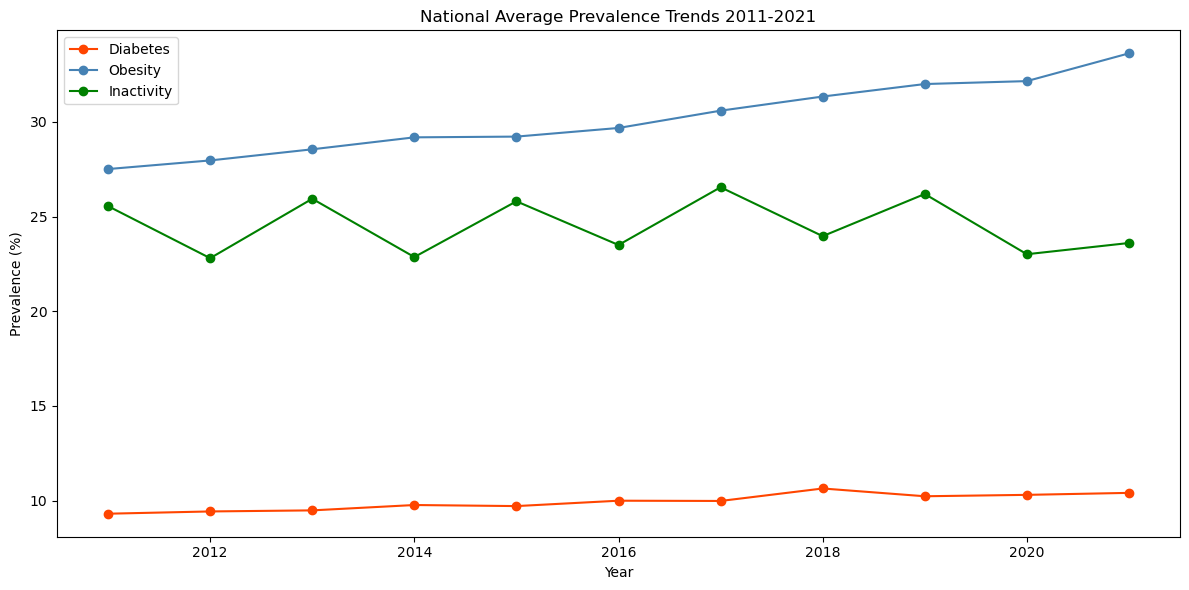

National trends chart saved!


In [4]:
# Looking at NAtioanl average trends over time 
df_trend = df.groupby('YearStart')[
    ['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']
].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_trend['YearStart'], df_trend['diabetes_prevalence'], 
         color='orangered', marker='o', label='Diabetes')
plt.plot(df_trend['YearStart'], df_trend['obesity_prevalence'], 
         color='steelblue', marker='o', label='Obesity')
plt.plot(df_trend['YearStart'], df_trend['inactivity_prevalence'], 
         color='green', marker='o', label='Inactivity')

plt.title('National Average Prevalence Trends 2011-2021')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.tight_layout()
plt.savefig(viz_path + "ts_national_trends.png", dpi=150)
plt.show()
print("National trends chart saved!")

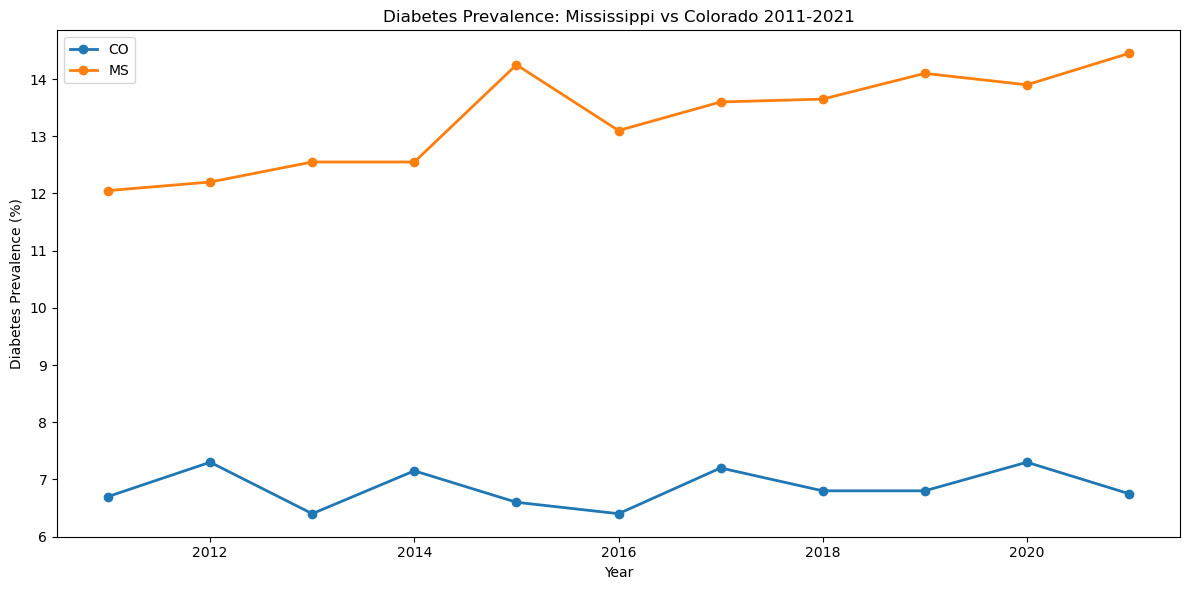

State comparison chart saved!


In [5]:
# Highlighting Mississippi Vs. Colorado
df_states = df[df['LocationAbbr'].isin(['MS', 'CO'])].copy()

plt.figure(figsize=(12, 6))
for state, group in df_states.groupby('LocationAbbr'):
    plt.plot(group['YearStart'], group['diabetes_prevalence'], 
             marker='o', label=state, linewidth=2)

plt.title('Diabetes Prevalence: Mississippi vs Colorado 2011-2021')
plt.xlabel('Year')
plt.ylabel('Diabetes Prevalence (%)')
plt.legend()
plt.tight_layout()
plt.savefig(viz_path + "ts_state_comparison.png", dpi=150)
plt.show()
print("State comparison chart saved!")

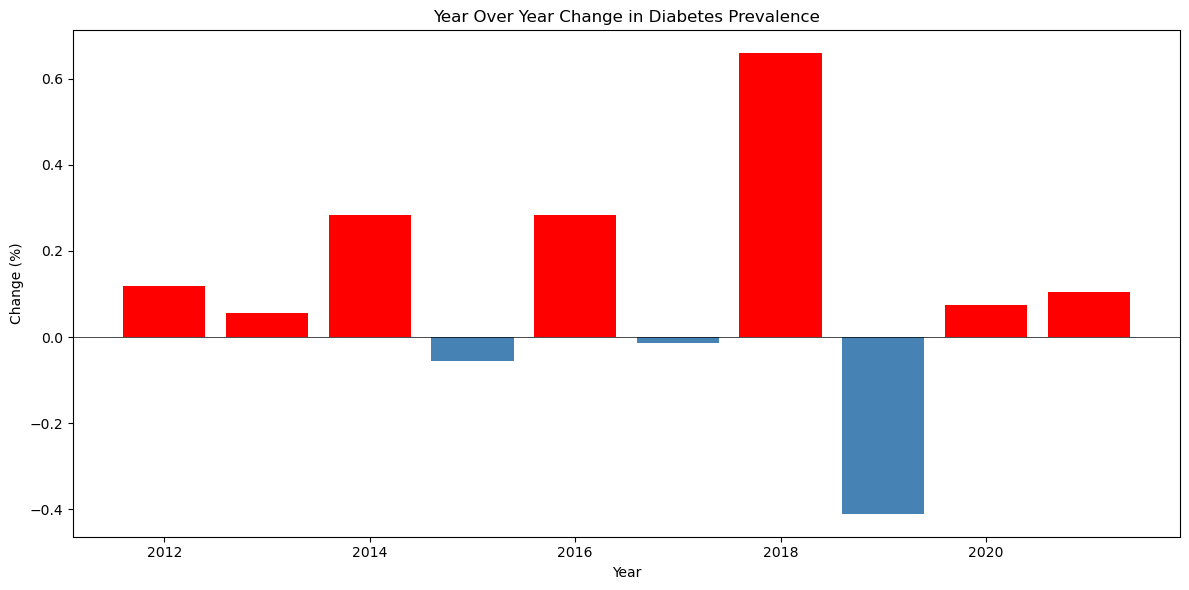

YoY chart saved!


In [6]:
# Checkignyear over year change
df_yoy = df_trend.copy()
df_yoy['diabetes_yoy'] = df_yoy['diabetes_prevalence'].diff()

plt.figure(figsize=(12, 6))
colors = ['red' if x > 0 else 'steelblue' for x in df_yoy['diabetes_yoy']]
plt.bar(df_yoy['YearStart'], df_yoy['diabetes_yoy'], color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Year Over Year Change in Diabetes Prevalence')
plt.xlabel('Year')
plt.ylabel('Change (%)')
plt.tight_layout()
plt.savefig(viz_path + "ts_yoy_change.png", dpi=150)
plt.show()
print("YoY chart saved!")

In [7]:
# Saving the results 
df_trend.to_csv(prepared_path + "cdi_time_series.csv", index=False)
print("Time series file saved! Notebook 06 complete!")

Time series file saved! Notebook 06 complete!
